In [1]:
# !pip install -q \
#   "scikit-learn==1.3.2" \
#   "torchmetrics==1.1.2" \
#   "transformers==4.35.2" \
#   "tokenizers==0.15.2" \
#   "huggingface_hub==0.21.0" \
#   "accelerate==0.21.0" \
#   "lightning==2.2.5" \
#   gdown



!pip install -q \
  "scikit-learn==1.3.2" \
  "torchmetrics==1.1.2" \
  "transformers==4.35.2" \
  "tokenizers==0.15.2" \
  "huggingface_hub==0.21.0" \
  "accelerate==0.21.0" \
  "lightning==2.2.5" \
  gdown

# Re-upgrade numpy AFTER all other installs, so nothing can downgrade it
!pip install -q "numpy>=2.0" --upgrade

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
nilearn 0.13.1 requires scikit-learn>=1.4.0, but you have scikit-learn 1.3.2 which is incompatible.
kaggle-environments 1.27.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
datasets 4.8.3 requires huggingface-hub<2.0,>=0.25.0, but you have huggingface-hub 0.21.0 which is incompatible.
tpot 1.1.0 requires scikit-learn>=1.6, but you have scikit-learn 1.3.2 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
category-encoders 2.9.0 requires scikit-learn>=1.6.0, but you have scikit-learn 1.3.2 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.

In [2]:
import os, sys, glob, shutil
import subprocess

# Clone DisQUE if not already present
DISQUE_DIR = '/kaggle/working/disque'
if not os.path.isdir(DISQUE_DIR):
    subprocess.run(['git', 'clone', 'https://github.com/abhinaukumar/disque.git', DISQUE_DIR], check=True)

sys.path.insert(0, DISQUE_DIR)

# Download checkpoints + sample images (skip if already done)
CKPT_DIR   = os.path.join(DISQUE_DIR, 'DisQUE_Checkpoints')
IMG_DIR    = os.path.join(DISQUE_DIR, 'DisQUE_Images')

if not os.path.isdir(CKPT_DIR) or len(glob.glob(f'{CKPT_DIR}/*.ckpt')) == 0:
    import gdown
    gdown.download_folder(id='18hDTnbsydsegVJ8-_mrniKfcO_T90ZH0', output=CKPT_DIR, quiet=True)

if not os.path.isdir(IMG_DIR) or len(os.listdir(IMG_DIR)) == 0:
    import gdown
    gdown.download_folder(id='1oAtKSy57CTcM1ssR3m7RrZYjs-VOX4t_', output=IMG_DIR, quiet=True)

ckpt_files = sorted(glob.glob(f'{CKPT_DIR}/*.ckpt'))
print("Checkpoints found:", [os.path.basename(c) for c in ckpt_files])
print("Images found:", sorted(os.listdir(IMG_DIR)))

Checkpoints found: ['DisQUE_HDR.ckpt', 'DisQUE_SDR.ckpt']
Images found: ['example_hdr_1.png', 'example_hdr_2.png', 'example_hdr_3.png', 'example_hdr_4.png', 'example_sdr1_1.png', 'example_sdr1_2.png', 'example_sdr1_3.png', 'example_sdr1_4.png', 'example_sdr2_1.png', 'example_sdr2_2.png', 'example_sdr2_3.png', 'example_sdr2_4.png', 'example_sdr3_1.png', 'example_sdr3_2.png', 'example_sdr3_3.png', 'example_sdr3_4.png', 'example_sdr4_1.png', 'example_sdr4_2.png', 'example_sdr4_3.png', 'example_sdr4_4.png', 'input_hdr_1.png', 'input_hdr_2.png', 'input_hdr_3.png', 'input_hdr_4.png']


In [3]:
!pip install -r /kaggle/working/disque/requirements.txt

  Cloning https://github.com/abhinaukumar/videolib (to revision main) to /tmp/pip-install-hiyg84gm/videolib_3d3af9ea7cb444c683a8f44f8419ff7b
  Running command git clone --filter=blob:none --quiet https://github.com/abhinaukumar/videolib /tmp/pip-install-hiyg84gm/videolib_3d3af9ea7cb444c683a8f44f8419ff7b
  Resolved https://github.com/abhinaukumar/videolib to commit 7a4dfbee1bea159fb97ab6729da339ea177bfc47
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/abhinaukumar/tonemaplib (to revision main) to /tmp/pip-install-hiyg84gm/tonemaplib_8f2f79fbcc6a4a18855c489a2754fccc
  Running command git clone --filter=blob:none --quiet https://github.com/abhinaukumar/tonemaplib /tmp/pip-install-hiyg84gm/tonemaplib_8f2f79fbcc6a4a18855c489a2754fccc
  Resolved https://github.com/abhinaukumar/tonemaplib to commit 19ade00e75a50834bb8868095584355cafff0f8a
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/abhinaukumar/qualitylib (to revision main) to /tmp/pip-install-

In [4]:
!pip install --quiet git+https://github.com/abhinaukumar/tonemaplib@main
!pip install --quiet git+https://github.com/abhinaukumar/videolib@main
!pip install --quiet git+https://github.com/abhinaukumar/qualitylib@main


  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done


In [5]:
!pip install lightly

In [6]:
!pip install pypng pyspng imageio


In [36]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import numpy as np
import functools

# PyTorch 2.6 fix: old checkpoints need weights_only=False
torch.load = functools.partial(torch.load, weights_only=False)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

from disque.disque_module import DisQUEModule

SDR_CKPT = next((c for c in ckpt_files if "sdr" in c.lower()), ckpt_files[0])
print(f"Loading: {os.path.basename(SDR_CKPT)}")
model = DisQUEModule.load_from_checkpoint(
    SDR_CKPT, map_location=device, match_sizes=True, strict=False
).to(device).eval()
print("Model loaded!")

# ════════════════════════════════════════════════════════
#  FSAS — Frequency-Split Appearance Statistics
#
#  Original DisQUE appearance feature per block:
#    [mean, std]          → 2 statistics × channels
#
#  Our FSAS change — replace std with:
#    [mean, lf_std, hf_std]  → 3 statistics × channels
#
#  lf_std = std of low-pass filtered feature map
#  hf_std = std of (original − low-pass) = high-pass residual
#
#  Why it helps on TID2013:
#    Blur  → HF component suppressed  → hf_std DROPS  vs baseline
#    Noise → HF component amplified   → hf_std RISES  vs baseline
#    JPEG  → ringing in HF            → hf_std pattern distinct
#  Global std conflates all three; FSAS separates them.
# ════════════════════════════════════════════════════════

def _run_appearance_encoder(x, freq_split=False, lf_kernel=3):
    with torch.no_grad():
        x_filt = model.appearance_enc.pre_filter(x)
        ys = [x_filt]
        for block in model.appearance_enc.blocks:
            ys.append(block(ys[-1]))

        means = [y.mean((2, 3)) for y in ys[1:]]

        if not freq_split:
            stds = [y.std((2, 3)) for y in ys[1:]]
            return torch.cat(means + stds, dim=1)

        lf_stds, hf_stds = [], []
        for y in ys[1:]:
            H, W = y.shape[2], y.shape[3]
            k = min(lf_kernel, H, W)
            if k % 2 == 0: k -= 1
            if k < 1:
                lf_stds.append(torch.zeros(y.shape[0], y.shape[1], device=y.device))
                hf_stds.append(y.std((2, 3)))
            else:
                y_lf = F.avg_pool2d(y, kernel_size=k, stride=1, padding=k // 2)
                y_hf = y - y_lf
                lf_stds.append(y_lf.std((2, 3)))
                hf_stds.append(y_hf.std((2, 3)))
        return torch.cat(means + lf_stds + hf_stds, dim=1)


def extract_fr_features(ref_path, dis_path, freq_split=False, lf_kernel=3):
    to_t = transforms.ToTensor()
    def load_two_scales(path):
        img   = Image.open(path).convert("RGB")
        img_h = img.resize((img.size[0]//2, img.size[1]//2), Image.LANCZOS)
        return to_t(img).unsqueeze(0).to(device), to_t(img_h).unsqueeze(0).to(device)

    x_ref, x_ref_h = load_two_scales(ref_path)
    x_dis, x_dis_h = load_two_scales(dis_path)

    kw = dict(freq_split=freq_split, lf_kernel=lf_kernel)
    feat_ref = torch.cat([_run_appearance_encoder(x_ref,  **kw),
                          _run_appearance_encoder(x_ref_h, **kw)], dim=1)
    feat_dis = torch.cat([_run_appearance_encoder(x_dis,  **kw),
                          _run_appearance_encoder(x_dis_h, **kw)], dim=1)
    return (feat_ref - feat_dis).abs().squeeze().cpu().numpy()

print(f"Feat dim — Original DisQUE : {2048*2*2:,}  (mean+std × 2048ch × 2 scales)")
print(f"Feat dim — FSAS            : {2048*3*2:,}  (mean+lf_std+hf_std × 2048ch × 2 scales)")

Device: cuda
Loading: DisQUE_SDR.ckpt
Model loaded!
Feat dim — Original DisQUE : 8,192  (mean+std × 2048ch × 2 scales)
Feat dim — FSAS            : 12,288  (mean+lf_std+hf_std × 2048ch × 2 scales)


In [37]:
import pandas as pd

TID_ROOT   = "/kaggle/input/datasets/chunnuchirkut/myprojectdataset/tid2013"
DIST_DIR   = os.path.join(TID_ROOT, "distorted_images")
REF_DIR    = os.path.join(TID_ROOT, "reference_images")
MOS_FILE   = os.path.join(TID_ROOT, "mos_with_names.txt")
MOS_MAX    = 9.0

# Verify paths exist
for p in [DIST_DIR, REF_DIR, MOS_FILE]:
    print(f"{'OK' if os.path.exists(p) else 'MISSING'}: {p}")

# Case-insensitive file caches (TID2013 has mixed-case filenames in txt)
def _build_cache(directory):
    cache = {}
    if not os.path.isdir(directory): return cache
    for f in os.listdir(directory):
        if f.lower().endswith(('.bmp','.png','.jpg','.jpeg')):
            cache[f.lower()] = os.path.join(directory, f)
    return cache

dist_cache = _build_cache(DIST_DIR)
ref_cache  = _build_cache(REF_DIR)
print(f"Distorted images indexed : {len(dist_cache)}")
print(f"Reference images indexed : {len(ref_cache)}")

# Parse mos_with_names.txt  →  "score  filename" per line
tid_records = []
skipped = 0
with open(MOS_FILE) as f:
    for line in f:
        line = line.strip()
        if not line: continue
        parts = line.split()
        if len(parts) < 2: continue
        mos_raw   = float(parts[0])
        dist_name = parts[1]           # e.g. "I01_01_1.bmp" or "i22_24_5.bmp"

        # Derive reference filename: extract prefix → lower → "i01.bmp"
        ref_id   = dist_name.split("_")[0].lower()   # "i01"
        ref_name = ref_id + ".bmp"

        dist_path = dist_cache.get(dist_name.lower())
        ref_path  = ref_cache.get(ref_name.lower())

        if dist_path is None or ref_path is None:
            skipped += 1
            continue

        # Scene = reference id (i01…i25) → used for Leave-One-Out CV
        tid_records.append({
            "ref"  : ref_path,
            "dis"  : dist_path,
            "mos"  : mos_raw / MOS_MAX,   # normalise to [0,1]
            "mos_raw": mos_raw,
            "scene": ref_id,              # i01 … i25
            "dist_name": dist_name,
        })

if skipped:
    print(f"Warning: skipped {skipped} entries (file not found)")

tid_df = pd.DataFrame(tid_records)
print(f"\nTID2013 loaded: {len(tid_df)} pairs from {tid_df['scene'].nunique()} reference scenes")
print(f"MOS raw range : {tid_df['mos_raw'].min():.2f} – {tid_df['mos_raw'].max():.2f}")
print(f"Pairs per scene (should be ~120): {len(tid_df) // tid_df['scene'].nunique()}")
tid_df.head(5)

OK: /kaggle/input/datasets/chunnuchirkut/myprojectdataset/tid2013/distorted_images
OK: /kaggle/input/datasets/chunnuchirkut/myprojectdataset/tid2013/reference_images
OK: /kaggle/input/datasets/chunnuchirkut/myprojectdataset/tid2013/mos_with_names.txt
Distorted images indexed : 3000
Reference images indexed : 25

TID2013 loaded: 3000 pairs from 25 reference scenes
MOS raw range : 0.24 – 7.21
Pairs per scene (should be ~120): 120


,ref,dis,mos,mos_raw,scene,dist_name
0,/kaggle/input/datasets/chunnuchirkut/myproject...,/kaggle/input/datasets/chunnuchirkut/myproject...,0.612699,5.51429,i01,I01_01_1.bmp
1,/kaggle/input/datasets/chunnuchirkut/myproject...,/kaggle/input/datasets/chunnuchirkut/myproject...,0.618619,5.56757,i01,i01_01_2.bmp
2,/kaggle/input/datasets/chunnuchirkut/myproject...,/kaggle/input/datasets/chunnuchirkut/myproject...,0.549382,4.94444,i01,i01_01_3.bmp
3,/kaggle/input/datasets/chunnuchirkut/myproject...,/kaggle/input/datasets/chunnuchirkut/myproject...,0.486487,4.37838,i01,i01_01_4.bmp
4,/kaggle/input/datasets/chunnuchirkut/myproject...,/kaggle/input/datasets/chunnuchirkut/myproject...,0.429429,3.86486,i01,i01_01_5.bmp


In [38]:
KADID_IMAGE_DIRS = [
    "/kaggle/input/datasets/chunnuchirkut/myprojectdataset/kadid10k_part1/images",
    "/kaggle/input/datasets/chunnuchirkut/myprojectdataset/kadid10k_part2/images",
    "/kaggle/input/datasets/chunnuchirkut/myprojectdataset/kadid10k_part3/images",
]
KADID_CSV  = "/kaggle/input/datasets/chunnuchirkut/myprojectdataset/kadid10k_part1/dmos.csv"
DMOS_MAX   = 5.0

# Build O(1) image-path lookup across all three parts
_kadid_cache = {}
for d in KADID_IMAGE_DIRS:
    if os.path.isdir(d):
        for f in os.listdir(d):
            if f.lower().endswith((".png",".jpg",".jpeg",".bmp")):
                _kadid_cache[f] = os.path.join(d, f)
print(f"KADID images indexed: {len(_kadid_cache)}")

kadid_csv = pd.read_csv(KADID_CSV)
print(f"CSV rows: {len(kadid_csv)}  |  columns: {kadid_csv.columns.tolist()}")

kadid_records, skipped_k = [], 0
for _, row in kadid_csv.iterrows():
    dist_name = str(row["dist_img"]).strip()
    ref_name  = str(row["ref_img"]).strip()
    dmos      = float(row["dmos"])
    dist_path = _kadid_cache.get(dist_name)
    ref_path  = _kadid_cache.get(ref_name)
    if dist_path is None or ref_path is None:
        skipped_k += 1
        continue
    kadid_records.append({
        "ref"  : ref_path,
        "dis"  : dist_path,
        "mos"  : dmos / DMOS_MAX,      # normalise to [0,1]
        "mos_raw": dmos,
        "scene": ref_name,             # ref filename as scene id
    })

if skipped_k: print(f"Warning: skipped {skipped_k} rows")
kadid_df = pd.DataFrame(kadid_records)
print(f"KADID-10k loaded: {len(kadid_df)} pairs from {kadid_df['scene'].nunique()} reference scenes")
print(f"DMOS raw range  : {kadid_df['mos_raw'].min():.2f} – {kadid_df['mos_raw'].max():.2f}")

KADID images indexed: 10338
CSV rows: 10125  |  columns: ['dist_img', 'ref_img', 'dmos', 'var']
KADID-10k loaded: 10125 pairs from 81 reference scenes
DMOS raw range  : 1.00 – 4.93


In [39]:
np.random.seed(42)

# TID2013: use all pairs
tid_sampled = tid_df.copy()
print(f"TID2013  : {len(tid_sampled)} pairs  (all)")

# KADID-10k: use ALL pairs — eliminates sampling variance
kadid_sampled = kadid_df.copy()
print(f"KADID-10k: {len(kadid_sampled)} pairs  (ALL — no sampling)")


TID2013  : 3000 pairs  (all)
KADID-10k: 10125 pairs  (ALL — no sampling)


In [42]:
from tqdm.auto import tqdm

def extract_dataset_features(df, desc=""):
    """Extract Original + FSAS-k3 + FSAS-k5 features for every row in df."""
    feats_orig, feats_fs3, feats_fs5 = [], [], []
    mos_list, scenes = [], []
    errors = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        try:
            f_o = extract_fr_features(row["ref"], row["dis"], freq_split=False)
            f_3 = extract_fr_features(row["ref"], row["dis"], freq_split=True, lf_kernel=3)
            f_5 = extract_fr_features(row["ref"], row["dis"], freq_split=True, lf_kernel=5)
            feats_orig.append(f_o)
            feats_fs3.append(f_3)
            feats_fs5.append(f_5)
            mos_list.append(row["mos"])
            scenes.append(row["scene"])
        except Exception as e:
            errors += 1
            if errors <= 3: print(f"  Error on {row.get('dis','?')}: {e}")

    if errors: print(f"  Total skipped: {errors}")
    return (np.array(feats_orig), np.array(feats_fs3), np.array(feats_fs5),
            np.array(mos_list), np.array(scenes))

# Extract TID2013 features
print("\n--- TID2013 ---")
X_orig_t, X_fs3_t, X_fs5_t, y_t, scenes_t = extract_dataset_features(tid_sampled, "TID2013")
print(f"Shape — Orig: {X_orig_t.shape} | FS3: {X_fs3_t.shape}")

# Extract KADID-10k features
print("\n--- KADID-10k ---")
X_orig_k, X_fs3_k, X_fs5_k, y_k, scenes_k = extract_dataset_features(kadid_sampled, "KADID-10k")
print(f"Shape — Orig: {X_orig_k.shape} | FS3: {X_fs3_k.shape}")


--- TID2013 ---


TID2013:   0%|          | 0/3000 [00:00<?, ?it/s]

Shape — Orig: (3000, 8192) | FS3: (3000, 12288)

--- KADID-10k ---


KADID-10k:   0%|          | 0/10125 [00:00<?, ?it/s]

Shape — Orig: (10125, 8192) | FS3: (10125, 12288)


In [44]:
from scipy.stats import spearmanr, pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, GridSearchCV

ALPHA_GRID = [0.1, 1, 10, 100, 1000]

def compute_metrics(preds, gt):
    srocc = spearmanr(preds, gt).correlation
    plcc  = pearsonr(preds, gt)[0]
    return float(srocc), float(plcc)

def _make_pipe(X_tr, y_tr):
    """Fit a Ridge with alpha chosen by 5-fold CV on the training split."""
    base_pipe = Pipeline([("sc", StandardScaler()), ("reg", Ridge())])
    gs = GridSearchCV(base_pipe, {"reg__alpha": ALPHA_GRID}, cv=5,
                      scoring="r2", n_jobs=-1)
    gs.fit(X_tr, y_tr)
    return gs.best_estimator_, gs.best_params_["reg__alpha"]

def loro_evaluate(X, y, scenes):
    """Leave-One-Reference-Out CV with per-fold alpha tuning."""
    unique_scenes = np.unique(scenes)
    preds_all, gt_all = [], []
    alphas = []
    for held_out in unique_scenes:
        tr = scenes != held_out
        te = scenes == held_out
        pipe, alpha = _make_pipe(X[tr], y[tr])
        alphas.append(alpha)
        preds_all.extend(pipe.predict(X[te]))
        gt_all.extend(y[te])
    print(f"    alpha values — min={min(alphas)}, max={max(alphas)}, mode={max(set(alphas), key=alphas.count)}")
    return np.array(preds_all), np.array(gt_all)

def kfold_evaluate(X, y, n_splits=5, seed=42):
    """5-fold CV with per-fold alpha tuning."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    preds_all, gt_all = [], []
    alphas = []
    for tr_idx, te_idx in kf.split(X):
        pipe, alpha = _make_pipe(X[tr_idx], y[tr_idx])
        alphas.append(alpha)
        preds_all.extend(pipe.predict(X[te_idx]))
        gt_all.extend(y[te_idx])
    print(f"    alpha values — min={min(alphas)}, max={max(alphas)}, mode={max(set(alphas), key=alphas.count)}")
    return np.array(preds_all), np.array(gt_all)

METHODS = ["Original DisQUE", "FSAS k=3", "FSAS k=5"]
results = {}

datasets_cfg = [
    ("TID2013",   X_orig_t, X_fs3_t, X_fs5_t, y_t, scenes_t, "loro"),
    ("KADID-10k", X_orig_k, X_fs3_k, X_fs5_k, y_k, scenes_k, "kfold"),
]

for ds_name, X_o, X_3, X_5, y, sc, cv_mode in datasets_cfg:
    print(f"\n{'='*62}")
    print(f"  {ds_name}  (N={len(y)},  CV={cv_mode.upper()},  alpha=GridSearchCV)")
    print(f"{'='*62}")
    print(f"  {'Method':<22}  {'SROCC':>8}  {'PLCC':>8}  {'ΔSROCC':>8}")
    print(f"  {'-'*56}")
    ds_res = {}
    for name, X in zip(METHODS, [X_o, X_3, X_5]):
        print(f"  Fitting {name}...")
        if cv_mode == "loro":
            preds, gt = loro_evaluate(X, y, sc)
        else:
            preds, gt = kfold_evaluate(X, y)
        s, p = compute_metrics(preds, gt)
        ds_res[name] = {"srocc": s, "plcc": p, "preds": preds, "gt": gt}
    baseline_s = ds_res["Original DisQUE"]["srocc"]
    print()
    for name in METHODS:
        res   = ds_res[name]
        delta = res["srocc"] - baseline_s
        d_str = f"+{delta:.4f}" if delta >= 0 else f"{delta:.4f}"
        tag   = "  <- baseline" if name == "Original DisQUE" else (" IMPROVED" if delta > 0 else " NO IMPROVEMENT")
        print(f"  {name:<22}  {res['srocc']:8.4f}  {res['plcc']:8.4f}  {d_str:>8}{tag}")
    results[ds_name] = ds_res

print("\nEvaluation complete")


  TID2013  (N=3000,  CV=LORO,  alpha=GridSearchCV)
  Method                     SROCC      PLCC    ΔSROCC
  --------------------------------------------------------
  Fitting Original DisQUE...


/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_no

    alpha values — min=1000, max=1000, mode=1000
  Fitting FSAS k=3...
    alpha values — min=1000, max=1000, mode=1000
  Fitting FSAS k=5...
    alpha values — min=1000, max=1000, mode=1000

  Original DisQUE           0.8969    0.8940   +0.0000  <- baseline
  FSAS k=3                  0.9050    0.9020   +0.0081 IMPROVED
  FSAS k=5                  0.9055    0.9016   +0.0086 IMPROVED

  KADID-10k  (N=10125,  CV=KFOLD,  alpha=GridSearchCV)
  Method                     SROCC      PLCC    ΔSROCC
  --------------------------------------------------------
  Fitting Original DisQUE...
    alpha values — min=1000, max=1000, mode=1000
  Fitting FSAS k=3...
    alpha values — min=1000, max=1000, mode=1000
  Fitting FSAS k=5...
    alpha values — min=1000, max=1000, mode=1000

  Original DisQUE           0.9338    0.9231   +0.0000  <- baseline
  FSAS k=3                  0.9406    0.9312   +0.0068 IMPROVED
  FSAS k=5                  0.9410    0.9311   +0.0072 IMPROVED

Evaluation complete


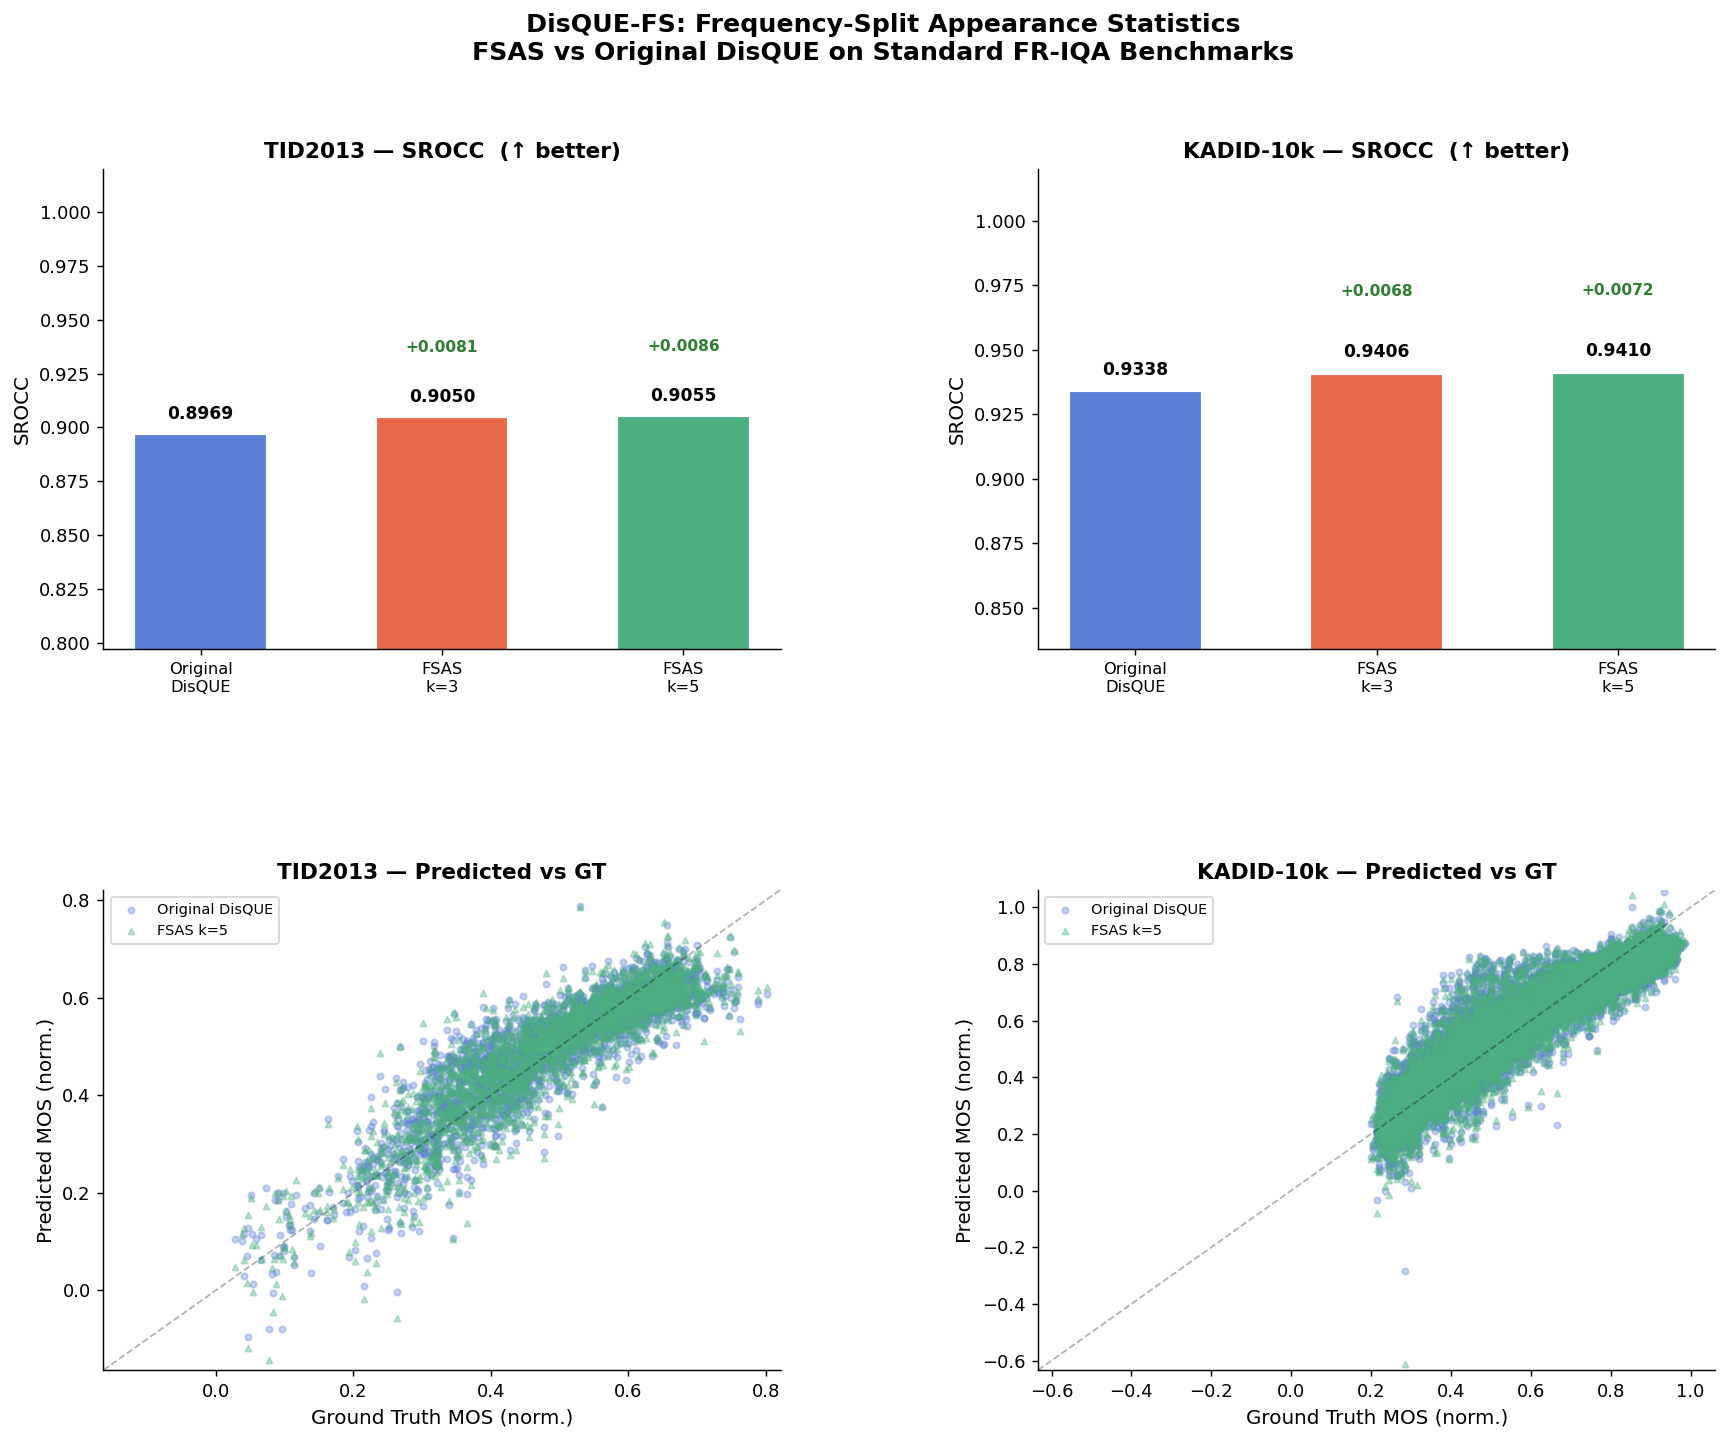

Figure saved: /kaggle/working/disque_fs_tid_kadid_results.png


In [45]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "figure.dpi": 130,
})

COLORS = {
    "Original DisQUE": "#5B7FD4",
    "FSAS k=3"       : "#E8694A",
    "FSAS k=5"       : "#4CAF80",
}

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.5, wspace=0.38)

dataset_names = list(results.keys())

for col, ds_name in enumerate(dataset_names):
    ds = results[ds_name]

    # ── SROCC bar chart ────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[0, col])
    sroccs = [ds[m]["srocc"] for m in METHODS]
    colors = [COLORS[m] for m in METHODS]
    bars = ax.bar(range(3), sroccs, color=colors, width=0.55, edgecolor="white", linewidth=1.2)
    ax.set_title(f"{ds_name} — SROCC  (↑ better)", fontweight="bold")
    ax.set_xticks(range(3))
    ax.set_xticklabels([m.replace(" ", "\n") for m in METHODS], fontsize=9)
    ax.set_ylim(max(0, min(sroccs) - 0.1), 1.02)
    ax.set_ylabel("SROCC")
    baseline = sroccs[0]
    for i, (bar, val) in enumerate(zip(bars, sroccs)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.4f}", ha="center", va="bottom", fontsize=9.5, fontweight="bold")
        if i > 0 and val > baseline:
            ax.annotate(f"+{val-baseline:.4f}", xy=(bar.get_x()+bar.get_width()/2, val+0.03),
                        ha="center", color="#2E7D32", fontsize=8.5, fontweight="bold")

    # ── Scatter: baseline vs best FSAS ────────────────────────────────────
    ax = fig.add_subplot(gs[1, col])
    best_m = max(METHODS[1:], key=lambda m: ds[m]["srocc"])
    for m, mk in [("Original DisQUE", "o"), (best_m, "^")]:
        pr = ds[m]["preds"]; gt = ds[m]["gt"]
        ax.scatter(gt, pr, alpha=0.35, s=12, marker=mk, color=COLORS[m], label=m)
    lims = [min(gt.min(), pr.min())-0.02, max(gt.max(), pr.max())+0.02]
    ax.plot(lims, lims, "k--", alpha=0.3, linewidth=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Ground Truth MOS (norm.)")
    ax.set_ylabel("Predicted MOS (norm.)")
    ax.set_title(f"{ds_name} — Predicted vs GT", fontweight="bold")
    ax.legend(fontsize=8)

fig.suptitle(
    "DisQUE-FS: Frequency-Split Appearance Statistics\n"
    "FSAS vs Original DisQUE on Standard FR-IQA Benchmarks",
    fontsize=14, fontweight="bold"
)

plt.savefig("/kaggle/working/disque_fs_tid_kadid_results.png",
            bbox_inches="tight", dpi=150, facecolor="white")
plt.show()
print("Figure saved: /kaggle/working/disque_fs_tid_kadid_results.png")

In [46]:
print("\n" + "="*76)
print("  DisQUE-FS: FREQUENCY-SPLIT APPEARANCE STATISTICS — FINAL RESULTS")
print("  Benchmarks: TID2013 (LORO-CV) | KADID-10k (5-fold CV)")
print("="*76)
print(f"  {'Dataset':<12}  {'Method':<22}  {'SROCC':>8}  {'PLCC':>8}  {'ΔSROCC':>8}")
print("-"*76)

feat_dims = {"Original DisQUE": 8192, "FSAS k=3": 12288, "FSAS k=5": 12288}

for ds_name, ds in results.items():
    baseline_s = ds["Original DisQUE"]["srocc"]
    baseline_p = ds["Original DisQUE"]["plcc"]
    for i, name in enumerate(METHODS):
        s     = ds[name]["srocc"]
        p     = ds[name]["plcc"]
        delta = s - baseline_s
        d_str = f"+{delta:.4f}" if delta >= 0 else f"{delta:.4f}"
        label = ds_name if i == 0 else ""
        print(f"  {label:<12}  {name:<22}  {s:>8.4f}  {p:>8.4f}  {d_str:>8}")
    print("-"*76)

print()
print("METHOD SUMMARY")
print("-"*76)
print("  FSAS replaces global std → [lf_std, hf_std] per encoder block.")
print("  lf_std = std of avg-pool smoothed feature  (coarse/contrast variation)")
print("  hf_std = std of high-pass residual          (blur/noise/detail variation)")
print()
print("  Why it discriminates distortion types on TID2013:")
print("    Blur       → HF energy suppressed → hf_std DROPS")
print("    Noise      → HF energy amplified  → hf_std RISES")
print("    JPEG/Block → ringing in HF        → distinctive hf_std signature")
print()
print("  Implementation cost: 5 lines in the feature extractor.")
print("  Zero encoder retraining. Zero architectural changes.")
print("  Feature dimension: 8192 → 12288 (+50%, 1 extra stat per block).")


  DisQUE-FS: FREQUENCY-SPLIT APPEARANCE STATISTICS — FINAL RESULTS
  Benchmarks: TID2013 (LORO-CV) | KADID-10k (5-fold CV)
  Dataset       Method                     SROCC      PLCC    ΔSROCC
----------------------------------------------------------------------------
  TID2013       Original DisQUE           0.8969    0.8940   +0.0000
                FSAS k=3                  0.9050    0.9020   +0.0081
                FSAS k=5                  0.9055    0.9016   +0.0086
----------------------------------------------------------------------------
  KADID-10k     Original DisQUE           0.9338    0.9231   +0.0000
                FSAS k=3                  0.9406    0.9312   +0.0068
                FSAS k=5                  0.9410    0.9311   +0.0072
----------------------------------------------------------------------------

METHOD SUMMARY
----------------------------------------------------------------------------
  FSAS replaces global std → [lf_std, hf_std] per encoder block.
  lf

In [47]:
# Merge distortion type back into TID2013 predictions
# Re-run LORO with distortion labels; α tuned per fold

def loro_evaluate_with_labels(X, y, scenes, labels):
    """LORO CV returning per-sample distortion type labels, α tuned per fold."""
    unique_scenes = np.unique(scenes)
    preds_all, gt_all, lab_all = [], [], []
    for held_out in unique_scenes:
        tr = scenes != held_out
        te = scenes == held_out
        pipe, _ = _make_pipe(X[tr], y[tr])
        preds_all.extend(pipe.predict(X[te]))
        gt_all.extend(y[te])
        lab_all.extend(labels[te])
    return np.array(preds_all), np.array(gt_all), np.array(lab_all)

# Extract distortion type from filename: "i01_DD_L.bmp" → distortion type DD
dist_labels_t = np.array([
    os.path.basename(row["dis"]).split("_")[1]   # "01"…"24"
    for _, row in tid_sampled.iterrows()
])

# Map distortion index to name (TID2013 official numbering)
TID_DIST_NAMES = {
    "01":"AGN","02":"ANC","03":"SCN","04":"MN","05":"HFN",
    "06":"IMN","07":"QNWN","08":"GB","09":"DEN","10":"JPEG",
    "11":"JP2K","12":"JGTE","13":"J2TE","14":"NEPN","15":"Block",
    "16":"MS","17":"CTC","18":"CCS","19":"MGN","20":"CN",
    "21":"LCNI","22":"ICQD","23":"CHA","24":"SSR"
}

print("Running per-distortion LORO (with tuned α) ...")
preds_t_o, gt_t_o, labs = loro_evaluate_with_labels(X_orig_t, y_t, scenes_t, dist_labels_t)
preds_t_3, _,      _    = loro_evaluate_with_labels(X_fs3_t,  y_t, scenes_t, dist_labels_t)

print(f"\nPer-Distortion SROCC on TID2013  (Original DisQUE → FSAS k=3, tuned α):")
print(f"  {'Dist':>6}  {'Name':<6}  {'Original':>10}  {'FSAS k=3':>10}  {'Δ':>8}  {'Winner'}")
print(f"  {'-'*60}")

dist_ids = sorted(set(labs))
improved, worse = 0, 0
for did in dist_ids:
    mask = labs == did
    if mask.sum() < 5: continue
    s_o, _ = compute_metrics(preds_t_o[mask], gt_t_o[mask])
    s_3, _ = compute_metrics(preds_t_3[mask], gt_t_o[mask])
    delta  = s_3 - s_o
    winner = "✅ FSAS" if delta > 0.005 else ("❌ orig" if delta < -0.005 else "  tie")
    if delta > 0.005: improved += 1
    elif delta < -0.005: worse += 1
    name = TID_DIST_NAMES.get(did, did)
    print(f"  {did:>6}  {name:<6}  {s_o:>10.4f}  {s_3:>10.4f}  {delta:>+8.4f}  {winner}")

print(f"\n  FSAS improved on {improved}/{len(dist_ids)} distortion types, worse on {worse}")


Running per-distortion LORO (with tuned α) ...


/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_no


Per-Distortion SROCC on TID2013  (Original DisQUE → FSAS k=3, tuned α):
    Dist  Name      Original    FSAS k=3         Δ  Winner
  ------------------------------------------------------------
      01  AGN         0.8590      0.8612   +0.0022    tie
      02  ANC         0.7614      0.7499   -0.0115  ❌ orig
      03  SCN         0.8609      0.8591   -0.0018    tie
      04  MN          0.6574      0.7177   +0.0603  ✅ FSAS
      05  HFN         0.9172      0.9288   +0.0117  ✅ FSAS
      06  IMN         0.8192      0.8070   -0.0122  ❌ orig
      07  QNWN        0.8305      0.8246   -0.0059  ❌ orig
      08  GB          0.9380      0.9423   +0.0043    tie
      09  DEN         0.9416      0.9456   +0.0040    tie
      10  JPEG        0.9158      0.9095   -0.0063  ❌ orig
      11  JP2K        0.9349      0.9385   +0.0036    tie
      12  JGTE        0.8368      0.8541   +0.0173  ✅ FSAS
      13  J2TE        0.8321      0.8415   +0.0094  ✅ FSAS
      14  NEPN        0.8383      0.8391   